In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def connectivity_scalar(gwl):
    """
    Lateral connectivity scalar as a function of groundwater level.

    Represents how hydraulically connected the soil system is at a given
    water table depth. When the water table is near the surface the system
    is fully connected; when deep it is nearly isolated.

    Piecewise linear:
        gwl >= -0.3 m :              scalar = 1.0
        -0.5 m < gwl < -0.3 m :     linear interpolation 1e-8 → 1.0
        gwl <= -0.5 m :              scalar = 1e-8

    Args:
        gwl (float or array): groundwater level [m], <= 0

    Returns:
        scalar (float or array): connectivity multiplier [-], in [1e-8, 1.0]
    """
    gwl_high = -0.3
    gwl_low  = -0.5
    s_high   = 1.0
    s_low    = 1e-8
    s_floor  = 1e-8

    t = (gwl - gwl_low) / (gwl_high - gwl_low)
    t = np.clip(t, 0.0, 1.0)
    scalar = s_low + t * (s_high - s_low)
    scalar = np.where(np.asarray(gwl) <= gwl_low, s_floor, scalar)

    if np.ndim(gwl) == 0:
        return float(scalar)
    return scalar

def connectivity_scalar_exp(gwl, gwl_high=-0.5, s_ref=1e-7, gwl_ref=-5.0):
    """
    Exponential decay connectivity scalar, clipped to 1.0 above gwl_high.
    Anchored at gwl_high so the transition is smooth (no discontinuity):
        gwl >= gwl_high :  scalar = 1.0
        gwl <  gwl_high :  scalar = exp(k * (gwl - gwl_high))
                        where k = ln(s_ref) / (gwl_ref - gwl_high)

    Args:
        gwl      (float or array): groundwater level [m], <= 0
        gwl_high (float): threshold above which scalar = 1.0 [m].
        s_ref    (float): scalar value at gwl_ref. Default 1e-7.
        gwl_ref  (float): reference depth [m] where scalar = s_ref.

    Returns:
        scalar (float or array): connectivity multiplier [-], in (0, 1.0]
    """ 

    k = np.log(s_ref) / (gwl_ref - gwl_high)
    scalar = np.exp(k * (np.asarray(gwl, dtype=float) - gwl_high))
    scalar = np.where(np.asarray(gwl) >= gwl_high, 1.0, scalar)

    if np.ndim(gwl) == 0:
        return float(scalar)
    return scalar

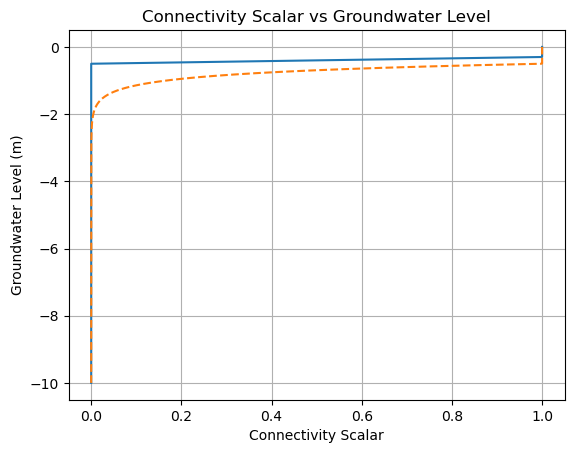

In [3]:
gwl_values = np.linspace(-10.0, 0.0, 1000)  # Groundwater levels from -1 m to 0 m
scalars = []
scalars_exp = []
for gwl in gwl_values:
    scalar = connectivity_scalar(gwl)
    scalars.append(scalar)
    scalar_exp = connectivity_scalar_exp(gwl)
    scalars_exp.append(scalar_exp)
plt.plot(scalars, gwl_values)
plt.plot(scalars_exp, gwl_values, linestyle='--')
plt.xlabel("Connectivity Scalar")
plt.ylabel("Groundwater Level (m)")
plt.title("Connectivity Scalar vs Groundwater Level")
#plt.xscale("log")
plt.grid(True)
plt.show()

In [4]:
def transmissivity(dz, Ksat, gwl):
    r""" Transmissivity of saturated layer.

    Args:
       dz (array):  soil compartment thickness, node in center [m]
       Ksat (array): horizontal saturated hydr. cond. [ms-1]
       gwl (float): ground water level below surface, <0 [m]

    Returns:
       Tr (array): tranmissivity [m2 s-1]
       Tr (array): tranmissivity [m2 s-1]
    """
    
    # midpoint of cell, soil surface at 0
    z = dz / 2 - np.cumsum(dz)

    # saturated layer thickness [m], between [0, dz]
    dz_sat = np.minimum(np.maximum(gwl - (z - dz / 2), 0), dz)
    # in top cell, allow transmissivity to increases when gwl above ground surface level
    dz_sat[0] = np.maximum(gwl - (z[0] - dz[0] / 2), 0)  
    
    # transmissivity of layers  [m2 s-1]
    Trans = Ksat * dz_sat

    # sum over layers
    Tr = np.maximum(sum(Trans), 1e-4 / 86400)

    return Tr * connectivity_scalar(gwl)

def transmissivity_exp(dz, Ksat, gwl):
    r""" Transmissivity of saturated layer.

    Args:
       dz (array):  soil compartment thickness, node in center [m]
       Ksat (array): horizontal saturated hydr. cond. [ms-1]
       gwl (float): ground water level below surface, <0 [m]

    Returns:
       Tr (array): tranmissivity [m2 s-1]
       Tr (array): tranmissivity [m2 s-1]
    """
    
    # midpoint of cell, soil surface at 0
    z = dz / 2 - np.cumsum(dz)

    # saturated layer thickness [m], between [0, dz]
    dz_sat = np.minimum(np.maximum(gwl - (z - dz / 2), 0), dz)
    # in top cell, allow transmissivity to increases when gwl above ground surface level
    dz_sat[0] = np.maximum(gwl - (z[0] - dz[0] / 2), 0)  
    
    # transmissivity of layers  [m2 s-1]
    Trans = Ksat * dz_sat

    # sum over layers
    Tr = np.maximum(sum(Trans), 1e-4 / 86400)

    return Tr * connectivity_scalar_exp(gwl)

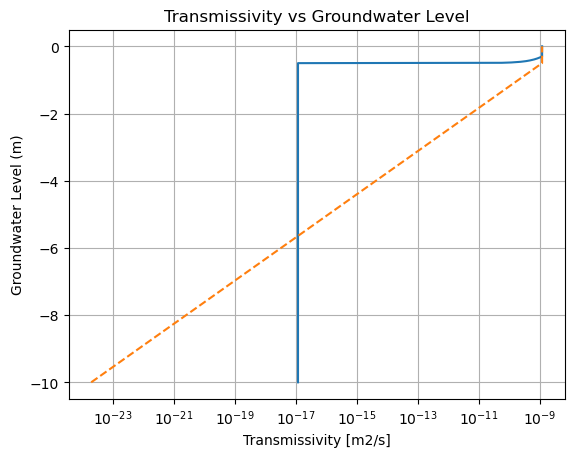

In [5]:
transmissivity_values = []
transmissivity_values_exp = []
dz = np.array([-0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0, -1.2, -1.4, -1.6, -1.8, -2.0, -2.5, -3.0, -3.5, -4.0, -5.0, -6.0, -7.0, -8.0, -9.0, -10.0])  # Example soil compartment thicknesses [m]
Ksat = np.array([2.74E-04, 1.51E-04, 8.27E-05, 4.54E-05, 2.5E-05, 1.38E-05, 7.6E-06, 4.21E-06, 2.36E-06, 1.34E-06, 4.73E-07, 2.12E-07, 1.34E-07, 1.1E-07, 1.03E-07, 1E-07, 1E-07, 1E-07, 1E-07, 1E-07, 1E-07, 1E-07, 1E-07, 1E-07, 1E-07])  # Example horizontal saturated hydraulic conductivities [m/s]  
for gwl in gwl_values:
    Tr = transmissivity(dz, Ksat, gwl)
    transmissivity_values.append(Tr)
    Tr_exp = transmissivity_exp(dz, Ksat, gwl)
    transmissivity_values_exp.append(Tr_exp)

plt.plot(transmissivity_values, gwl_values)
plt.plot(transmissivity_values_exp, gwl_values, linestyle='--')
plt.xlabel("Transmissivity [m2/s]")
plt.ylabel("Groundwater Level (m)")
plt.title("Transmissivity vs Groundwater Level")
plt.xscale("log")
plt.grid(True)
plt.show()